<a href="https://colab.research.google.com/github/CorinnnaZ/CompChallenge/blob/main/extension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extension


### Part I: EyeBall
I would like to do geometric optics on an eye. Not for Andrew French's suggestion of the physics being analysed to help improve people's vision but focusing on raindrops and the refraction of white light in water.

All parameters of this should be accounted for since I want a visualisation - without any quantum effects - of Rayleigh Scattering, where shorter wavelength light scatter more than longer wavelength light.

I would like this to run as a simulation that can be pretty crudely analysed and demonstrated.

*For this section, just a simple plotting of the interaction of a ray onto a surface whose internal refractive index is that of water is all that is necessary.*

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as ipy
import random

There are two roots from this.
There is a chance that it is tangential, meaning the root is repeated.


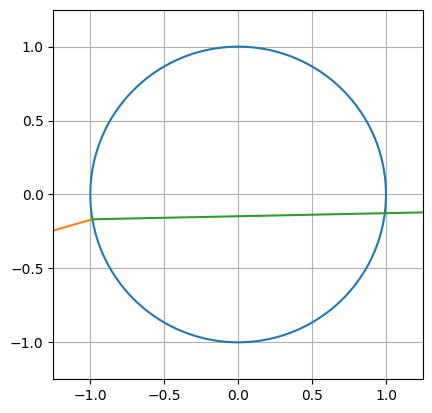

In [ ]:
# plotting environment
fig, ax = plt.subplots()

# circle
t = np.arange(0, (2 * np.pi), 0.0025)

x = np.cos(t)
y = np.sin(t)

ax.plot(x,y)

# randomised line
m_1 = np.random.uniform(-1, 1) # gradient
y_1 = np.random.uniform(-1, 1) # y_intercept

a = (m_1 ** 2) + 1
b = (2 * m_1 * y_1)
c = (y_1 ** 2) - 1

### check discriminant
d = (b ** 2) - (4 * a * c)

### solve equation
x_values = []
if d < 0:
    print("There are no real solutions to this.\nOnly a circle will be plotted.")
elif d >= 0:
    print("There are two roots from this.\nThere is a chance that it is tangential, meaning the root is repeated.")
    x1 = (-b+np.sqrt(b**2-4*a*c))/(2*a)
    x2 = (-b-np.sqrt(b**2-4*a*c))/(2*a)
    x_values.extend([x1, x2])

min_x = min(x_values) # where the line first intersects the circle (from the left)

x_l = np.linspace(-5, min_x, 1000)
y_l = (m_1 * x_l) + y_1

ax.plot(x_l, y_l)
# refraction handling
n_1 = 1 # air
n_2 = 13.3 # water

theta_1 = np.arctan(m_1) # converts the initial randomised gradient into an angle
theta_2 = np.arcsin((n_1 / n_2) * np.sin(theta_1))  # Correct Snell's law

m_2 = np.tan(theta_2) # gradient of refracted ray
x_i, y_i = min_x, ((m_1 * min_x) + y_1) # intersection points of incident line and circle

x_r = np.linspace(x_i, 10, 1000) # I will calculate the emergent point later
y_r = m_2 * (x_r - x_i) + y_i

ax.plot(x_r, y_r)
# emergence handling

# plotting parameters
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect(1)
ax.grid()

#ax.legend()

## now try to put this into a class where I can change n and automatically 15 lines do this

### Part II: Classes & Boids
The detailed model of the one *EyeBall* can then be "extrapolated" onto an $n$-number of raindrops where an array of white light can be shone onto the environment and these reactions can take place to show what is happening

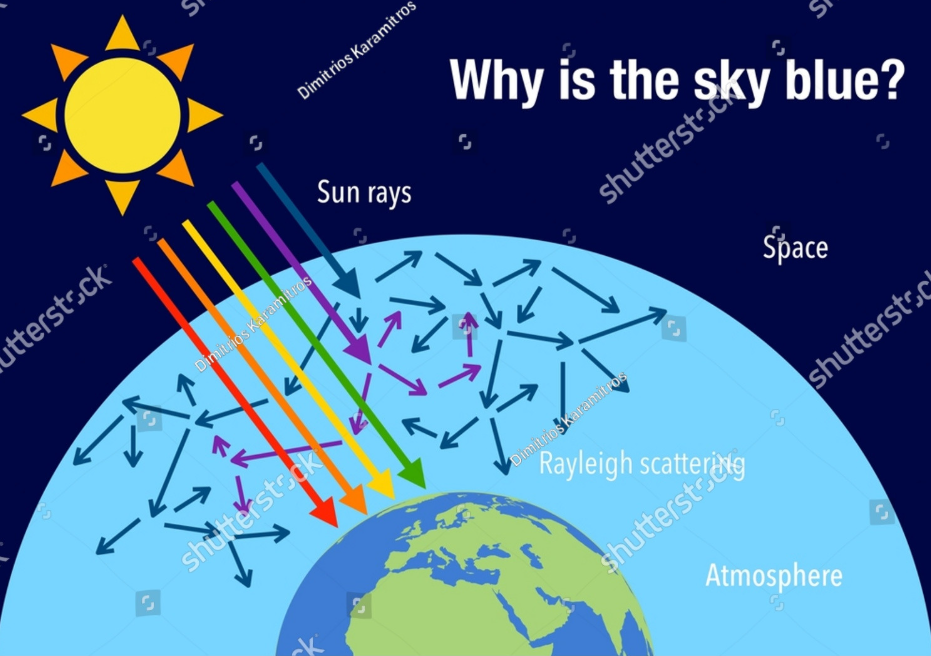

The above image is all that I want to do: I just want a source (the entire left wall) that emits discrete wavelengths of light (ranging from violet to red) and demonstrating the scattering effect in a geometric way.

### Next Steps
- Complete all notes up until the AtmosphericDroplet class (they are quite simple maths to do)
- Test plotting of the ray dynamics and what needs immediate improvements:
    - *Try to get to a stage where the rays can plot and refract through the circles (or at least one).* **How to define time step?**
- Work on the definition of time step
- Debug iteratively

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
import matplotlib.cm as cm

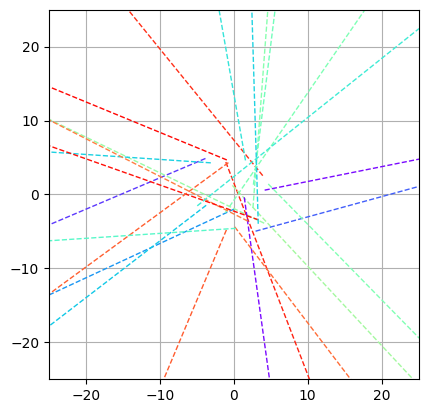

In [4]:
class Ray:
    def __init__(self, position, direction, wavelength):
        self.position = (position[0], position[1]) # starting vector position on the map

        self.direction = (direction[0], direction[1])  # to be vectorised to make later calcuations easier
                                                       # nonetheless, they will have to be parametrised for easier handling
        self.wavelength = wavelength # nanometre input

        """
        I initially included intensity into this model, but I do not understand how I would incorporate this into the vector display of the rays.
        If I have the time later, I will add it.
        """

    def get_refractive_index(self):
        # wavelength are inputted in metres
        # currently using emperical values for this equation

        # input wavelength
        c = 3e8
        w = self.wavelength * 1e-9 # convert nanometre input into metres
        f = c / w
        n = np.sqrt(1 + (np.sqrt(1/(1.731 - 0.261 * ((f/1e15) ** 2)))))

        # colour map (copied from task 1b)
        wavelength_nanometres = np.arange(405, 795, 1)
        true_wavelength_list = [(i/(10**9)) for i in wavelength_nanometres] # in metres
        frequency_list = [(c/wl) for wl in true_wavelength_list] # in Hz

        n_list = []
        for frequency in frequency_list:
            embed_1 = np.sqrt(1/(1.731 - 0.261 *((frequency/(10**15))**2)))
            n_discrete = np.sqrt(embed_1 + 1)
            n_list.append(n_discrete)

        colours = cm.rainbow(np.linspace(0,1,len(n_list)))

        ## find the position of n in n_list
        n_index = n_list.index(n)
        ## index the same in the colours list
        colour = colours[n_index]

        return n, colour

    def ray_plotting(self): # this type of plotting only occurs if there is no intersection between a ray and a raindrop
        """
        Define this plotting function of displaying just a white line that pertains to the colour of the inputted wavelength.
        Since this should be done automatically, I will use the matplotlib colours thing (matplotlib.cm)
        Then, the index of the wavelength in this list will be the colour that will be plotted
        """
        n, colour = self.get_refractive_index()

        dx, dy = self.direction[0], self.direction[1]
        x, y = self.position[0], self.position[1]
        t = np.linspace(0, 500, 10000)
        x_plot = [(x + t * dx) for t in t]
        y_plot = [(y + t * dy) for t in t]

        return [(x_plot, y_plot), colour]

for i in range(25):
    a = np.random.uniform(-5,5)
    b = np.random.uniform(-5,5)
    c = np.random.uniform(-5,5)
    d = np.random.uniform(-5,5)
    e = np.random.choice(np.arange(405, 795, 1))

    ray = Ray((a,b), (c,d), e)
    plotting, colour = ray.ray_plotting()
    plt.plot(plotting[0], plotting[1], "--", color=colour, linewidth=1)

lim = 25

plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.gca().set_aspect(1)
plt.grid()
plt.show()

In [36]:
class RainDrop:
    def __init__(self, centre, radius):
        self.centre = (centre[0], centre[1]) # this will be updated with the collision aspect of it. To be implemented later
        self.radius = radius

    def equation_for_raindrop(self):
        t = np.linspace(0, 2*np.pi, 1000)

        x = self.radius * np.cos(t)
        y = self.radius * np.sin(t)

        return [(x + self.centre[0]),(y + self.centre[1])]

    def find_intersection(self, ray):
        x_1, y_1 = ray.position # starting point of ray
        dx, dy = ray.direction  # direction vector
        x_2, y_2 = self.centre  # circle centre
        r = self.radius

        """
        How would I know which intersection point to choose.
        To begin with I would just choose the value with the minimum x value, since the ray was always going to move from left to right.
        This is no longer the case, given the internal reflections of the rays, which will cause it to occur at any side.
        How to handle?
        """
        # parametric equations in terms of t: at^2 + bt + c = 0
        # x = x_1 + t * dx ; y = y_1 + t * dy
        """
        This can handle when dx=0 which is much more likely in this instance given how many rays there will be.
        Thus, I will use this parametric form.
        """
        a = dx**2 + dy**2                           # t**2
        b = 2*(dx*(x_1 - x_2) + dy*(y_1 - y_2))     # t
        c = (x_1 - x_2)**2 + (y_1 - y_2)**2 - r**2  # constant

        # discriminant conditionals
        d = b**2 - 4*a*c

        """
        Return options:
        1. Two distinct roots
        2. Repeated root
        3. They do not intersect therefore output is None # this shoudld be handled well in other circumstances
        """

        if d < 0: # no real solutions
            return None
        elif d == 0: # repeated root
            t = - b / (2*a)
            if t >= 0: # further along the ray than starting point
                x = x_1 + t*dx
                y = y_1 + t*dy
                return (x,y)
            else:
                return None
        else: # two distinct roots, d>0
            t1 = (- b + np.sqrt(d)) / (2 * a)
            t2 = (- b - np.sqrt(d)) / (2 * a)

            # validate t and choose the closest intersection point
            # otherwise it would randomly migrate to the other side of the raindrop
            validated_t = [t for t in [t1, t2] if t>=0]

            if len(validated_t) == 0:
                return None
            else:
                t = min(validated_t)
                x = x_1 + t*dx
                y = y_1 + t*dy

                return (x,y)

    def get_surface_normal(self, intersection_point):
        if intersection_point is None:
            print("These points do not intersect") # can only do this with initial tests of the code
            return None
        else:
            cx, cy = self.centre
            ix, iy = intersection_point

            # Vector from center to intersection
            normal_x = (ix - cx) / self.radius
            normal_y = (iy - cy) / self.radius

            m = normal_y/normal_x

            return (normal_x, normal_y), m

    def refraction_ray(self, ray, intersection_point):
        """
        Since the normal line "extrudes" out of the surface, I will be using the dot product rule to help in determining whether the ray
        is leaving the circle or entering it. This would save furthe calculations and is an elegant way of working around this.

        The dot product effectively shows to what extend two objects are pointing in the same direction, the output of which being a scalar value.

        If the dot product (d) > 0, they are rougly pointing in the same direction.
        If the dot product (d) < 0, they are rougly pointing in opposite directions.
        """

        normal_data = self.get_surface_normal(intersection_point)
        normal = normal_data[0]
        dot_product = np.dot(ray.direction, normal)

        dx, dy = ray.direction[0], ray.direction[1]

        ###
        # For each of these instances, calculate and return the emergent ray direction
        # Update this direction for the ray (i.e. change the ray's direction outside of this function for it to be the input somewhere else)
        ###

        if dot_product<0: # i.e. entering the ray since opposite directions
            print("Inident ray entering raindrop: air to water")
            n1, n2 = 1.0, ray.get_refractive_index()[0] # n_air ~ 1
            # inward facing side of normal is necessary for refracted calculation

            n_x, n_y = -normal[0], -normal[1] # vector of normal

            theta = np.arccos((dot_product)/(np.linalg.norm(ray.direction) * np.linalg.norm(normal)))
            phi = np.arcsin((n1 * np.sin(theta))/(n2))

            # calculated derivation of this equation is in write-up
            # these are the coefficients of the equation solving for the y-component of the refracted ray

            gamma = np.linalg.norm(normal) * np.cos(phi)

            a = (n_y **2)/(n_x ** 2)
            b = (1 - (2 * n_y * gamma))/(n_x ** 2)
            c = ((gamma ** 2)/(n_x ** 2)) - 1

            d = (b ** 2) - (4 * a * c)

            if d < 0:
                raise ValueError(f"Discriminant, {d}, must not be negative")

            r_y1 = (-b + np.sqrt(d)) / (2 * a)
            r_y2 = (-b - np.sqrt(d)) / (2 * a)

            r_x1 = np.sqrt(1 - (r_y1 ** 2))
            r_x2 = np.sqrt(1 - (r_y2 ** 2))

            """
            Choose the vector with the smaller dot product.
            For the emergent ray I will choose the larger dot product.
            I think this makes sense.
            """

            vec_1 = (r_y1, r_x1)
            vec_2 = (r_y2, r_x2)

            dot_1 = np.dot(vec_1, (dy, dx))
            dot_2 = np.dot(vec_2, (dy, dx))

            # this handling is exceptionally inefficient
            if dot_1 > dot_2:
                # choose dot_2
                t = np.linspace(0, 400, (400*3))

                x = intersection_point[0] + (t * r_x2)
                y = intersection_point[1] + (t * r_y2)
                return (x, y)
            else:
                # choose dot_1
                t = np.linspace(0, 400, (400*3))

                x = intersection_point[0] + (t * r_x1)
                y = intersection_point[1] + (t * r_y1)
                return (x, y)

        else:  # exiting droplet
            print("Emergent ray exiting raindrop: water to air")
            n1, n2 = ray.get_refractive_index()[0], 1.0
            n_x, n_y = normal[0], normal[1]

            theta = np.arccos((dot_product)/(np.linalg.norm(ray.direction) * np.linalg.norm(normal)))
            phi = np.arcsin((n2 * np.sin(theta))/(n1))

            # calculated derivation of this equation is in write-up
            # these are the coefficients of the equation solving for the y-component of the refracted ray

            gamma = np.linalg.norm(normal) * np.cos(phi)

            a = (n_y **2)/(n_x ** 2)
            b = (1 - (2 * n_y * gamma))/(n_x ** 2)
            c = ((gamma ** 2)/(n_x ** 2)) - 1

            d = (b ** 2) - (4 * a * c)

            if d < 0:
                raise ValueError(f"Discriminant, {d}, must not be negative")

            r_y1 = (-b + np.sqrt(d)) / (2 * a)
            r_y2 = (-b - np.sqrt(d)) / (2 * a)

            r_x1 = np.sqrt(1 - (r_y1 ** 2))
            r_x2 = np.sqrt(1 - (r_y2 ** 2))

            """
            Choose the vector with the smaller dot product.
            For the emergent ray I will choose the larger dot product.
            I think this makes sense.
            """

            vec_1 = (r_y1, r_x1)
            vec_2 = (r_y2, r_x2)

            dot_1 = np.dot(vec_1, (dy, dx))
            dot_2 = np.dot(vec_2, (dy, dx))

            # this handling is exceptionally inefficient
            if dot_1 > dot_2:
                # choose dot_2
                t = np.linspace(0, 400, (400*3))

                x = intersection_point[0] + (t * r_x1)
                y = intersection_point[1] + (t * r_y1)
                return (x, y)
            else:
                # choose dot_1
                t = np.linspace(0, 400, (400*3))

                x = intersection_point[0] + (t * r_x2)
                y = intersection_point[1] + (t * r_y2)
                return (x, y)


9988
0
[np.float64(-0.5158816811369744), np.float64(-0.5339065566590845), np.float64(-0.5519314321811946), np.float64(-0.5699563077033047), np.float64(-0.5879811832254147), np.float64(-0.6060060587475249), np.float64(-0.624030934269635), np.float64(-0.642055809791745), np.float64(-0.6600806853138551), np.float64(-0.6781055608359652), np.float64(-0.6961304363580753), np.float64(-0.7141553118801853), np.float64(-0.7321801874022955), np.float64(-0.7502050629244055), np.float64(-0.7682299384465157), np.float64(-0.7862548139686257), np.float64(-0.8042796894907358), np.float64(-0.8223045650128459), np.float64(-0.8403294405349561), np.float64(-0.858354316057066), np.float64(-0.8763791915791762), np.float64(-0.8944040671012863), np.float64(-0.9124289426233964), np.float64(-0.9304538181455064), np.float64(-0.9484786936676166), np.float64(-0.9665035691897266), np.float64(-0.9845284447118368), np.float64(-1.0025533202339467), np.float64(-1.020578195756057), np.float64(-1.0386030712781669), np.flo

ValueError: x and y must have same first dimension, but have shapes (9988,) and (1,)

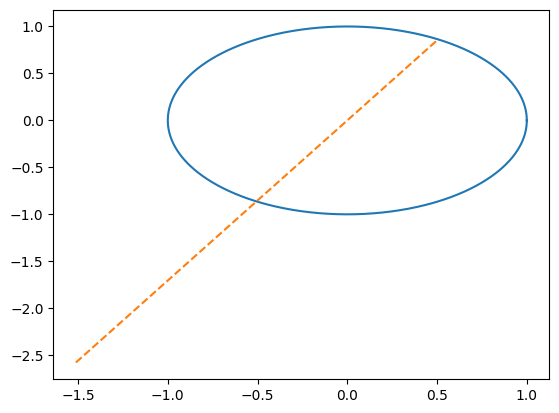

In [40]:
"""
This all works, but things to directly improve before the final step.

- Normal line plotting too far
- The handling of when lines do not intersect needs attention and a robust way of plotting:
    - Both the light_beam and droplet are shown on the plot within set bounds that doesn't cause the light_beam to plot forever
"""



a = [np.random.uniform(-2,2) for i in range(7)]

droplet = RainDrop((0, 0), 1)
light_beam = Ray((a[3],a[4]), (a[5], a[6]), 500)
intersection_point = droplet.find_intersection(light_beam)


drop_coor = droplet.equation_for_raindrop()
plt.plot(drop_coor[0], drop_coor[1], '-')

normal = droplet.get_surface_normal(intersection_point)
coor, m = normal[0], normal[1]
x = np.linspace(intersection_point[0] - np.abs(intersection_point[0] - (droplet.radius/2)), intersection_point[0] + np.abs(intersection_point[0] - (droplet.radius/2)),100)
y = (m*(x - intersection_point[0])) + intersection_point[1]
plt.plot(x, y, '--', label='normal')

plotting, colour = light_beam.ray_plotting()
x_l, y_l = plotting[0], plotting[1]
x_l = [x_l for x_l in x_l if x_l<intersection_point[0]]
print(len(x_l))
print(x_l.index(max(x_l)))
inin = x_l.index(max(x_l))
print(x_l)
print(y_l[:inin +1])
plt.plot(x_l, y_l[:inin + 1], '--', color=colour)

normal_plotting = droplet.refraction_ray(light_beam, intersection_point)
plt.plot(normal_plotting[0], normal_plotting[1], '--', color=colour)

plt.xlim(-5, 5)
plt.ylim(-5,5)

plt.grid()
plt.gca().set_aspect(1)
plt.legend()
plt.show()

**As one of the extensions, have it that the raindrops cannot overlap with each other.**

**As another extension, have these raindrops move ambiently in the environment (and the whole scene is an animated fiasco) and the light rays are animated with a temp step iteration (which will help with the data analysis plotting)**


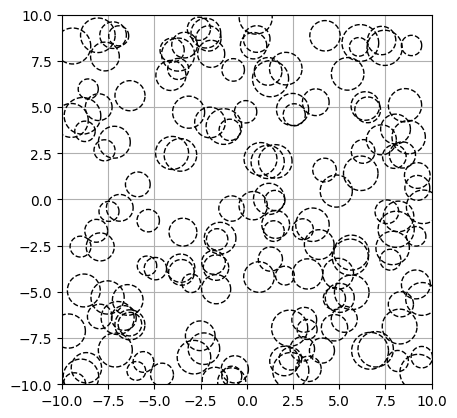

In [ ]:
for i in range(150):
    m = np.random.uniform(-10,10)
    n = np.random.uniform(-10,10)
    k = np.random.uniform(0.5, 1)
    rain = RainDrop((m,n), k).equation_for_raindrop()
    plt.plot(rain[0], rain[1], "--", color='k', linewidth=1)

plt.grid()
plt.gca().set_aspect(1)
plt.xlim(-10,10)
plt.ylim(-10, 10)
plt.show()

In [ ]:
class AtmosphericDroplet(RainDrop):  # Developing the model to be closer to what I want
    def __init__(self, centre, radius, altitude):
        super().__init__(centre, radius)
        self.altitude = altitude # refractive index changes with altitude (so something to factor in)

In [ ]:
class Atmosphere(): # plotting environment
    def __init__(self, width, height, num_droplets=100):
        self.width = width
        self.height = height
        self.droplets = []
        self.generate_droplets(num_droplets)

    def generate_droplets(self, num_droplets):
        for i in range(num_droplets):
            x = np.random.uniform(0, width)
            y = np.random.uniform(0, height)
            radius = np.random.uniform(0.5, 2)
            self.droplets.append(Raindrop((x,y), radius)) # change to AtmosphericDroplet when I add some function to do with altitude
        pass

### Part III: Data Analysis
*Unironically might spend time after this trying to clean it up*

Something simple that can help to visualise the messiness of this 8GB laptop. Maybe the visual aspect is neglected and instead I have graphs that show the instance of frequencies of light (indicating each of the 8(?) colours of the rainbow) that will hopefully rest on shorter wavelengths.

Then, in the video, I can say that the use of abstractions like this can help physicists to see whether experiments are first worth pursuing and are helpful in explaining concepts at a higher level.

### Pseudocode
- The simulation above will run for a defined number of time steps with a defined (and equal) number of the discrete rays of light.
- The final position of these rays of light will be the input here.
- Then, I will do a coloured heatmap that specifies where specifically each colour is of the highest density
- All data analysis completed